## 01. Data Exploration and Exploratory Data Analysis

In [69]:
from sklearn.preprocessing import LabelEncoder
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

df = pd.read_csv('../data/raw/ph_sms_dataset.csv')
df.sample(10)

,masked_celphone_number,hashed_cellphone_number,date,text,carrier,Target
968,+63909****826,d377c2af-cb00-3b8c-ba78-8f3c22de5bb5,2022-11-18 01:29:52.274,"Hottest News! Join JB Day, Make it your day! S...",TNT,Spam
296,+63985****893,d192505c-989a-339f-b12a-45db46c84779,2024-04-07 03:24:23.769,"kuya, ate Magdeposito at makakuha ng 100% bo...",Smart/TNT,Smishing (scam)
569,225655759,c30fb04f-ec2f-347d-a02c-f0bd643499c8,2024-02-03 04:46:12.000,Valid,<unknown>,Legitimate (ham)
474,+63964****124,14516805-693e-3968-86b0-5fbcb2453a9f,2024-02-27 11:08:03.886,cassenatrundling.si/5abxisj5 100% deposit bonu...,Globe,Smishing (scam)
985,+63933****843,baed4e31-9282-35a4-b14f-e51e7a384afa,2019-08-26 03:19:55.621,"NEED CASH? Meron Ka Bang FULLY PAID NA ""CAR & ...",Sun,Legitimate (ham)
893,+63909****281,1767a6ea-ad5b-386a-b952-a46bf2d85b9c,2023-01-29 03:42:24.041,"<REAL NAME>, Let's WINE UP! Deposit daily and ...",TNT,Smishing (scam)
322,+63964****255,74e0cac0-0403-3df5-b973-b1d8ca3ffd16,2024-04-04 00:17:08.628,1000% Luck bonus on ₱1000 balance. Register: p...,Globe,Smishing (scam)
249,+63985****418,c3639637-c718-3c93-a3d9-cbd5b0e17b73,2024-04-24 10:52:30.244,"Mag-recharge get 100% bonus, gamitin ang 100 p...",Smart/TNT,Smishing (scam)
751,+63985****431,0783cf50-5429-3e02-b4cd-1b223e5574c4,2023-08-23 04:26:29.646,"<REAL NAME>, Ready to play & win SUGARPLAY off...",Smart/TNT,Spam
542,+63930****743,8fefbbd1-b563-35e0-94c9-2691b51bc4d9,2024-02-12 16:27:10.289,NEED CASH? We are here for you.\n\nWe offer EA...,TNT,Spam


In [70]:
df.shape

(1021, 6)

In [71]:
df.isna().sum()

masked_celphone_number     0
hashed_cellphone_number    0
date                       0
text                       0
carrier                    0
Target                     0
dtype: int64

In [72]:
df.duplicated().sum()

np.int64(0)

In [73]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1021 entries, 0 to 1020
Data columns (total 6 columns):
 #   Column                   Non-Null Count  Dtype
---  ------                   --------------  -----
 0   masked_celphone_number   1021 non-null   str  
 1   hashed_cellphone_number  1021 non-null   str  
 2   date                     1021 non-null   str  
 3   text                     1021 non-null   str  
 4   carrier                  1021 non-null   str  
 5   Target                   1021 non-null   str  
dtypes: str(6)
memory usage: 48.0 KB


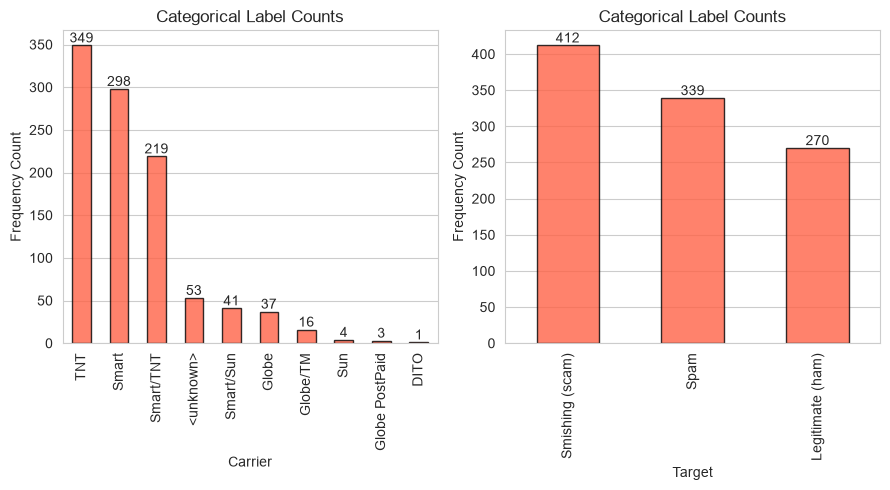

In [74]:
categoricals = ['carrier', 'Target']

fig, ax = plt.subplots(1, 2, figsize=(9, 5))

sns.set_style('whitegrid')
for i, cats in enumerate(categoricals):
    counts = df[cats].value_counts().sort_values(ascending=False)
    counts.plot(kind='bar', alpha=0.8, ax=ax[i], edgecolor='black', color='tomato')
    ax[i].set_ylabel('Frequency Count')
    ax[i].set_xlabel(f"{cats.title()}")
    ax[i].set_title('Categorical Label Counts')
    ax[i].bar_label(ax[i].containers[0])
    ax[i].grid(axis='x')
plt.tight_layout()


## Data Cleaning

In [75]:

def transform(df: pd.DataFrame) -> pd.DataFrame:

    if df.empty:
        raise ValueError("The DataFrame is Empty.")

    data = df.copy()

    try:

        encoder = LabelEncoder()
        # drop masked and hashed phone number
        data = data.drop(['masked_celphone_number', 'hashed_cellphone_number'], axis=1)

        # normalizing the date values
        data['date'] = pd.to_datetime(data['date'])

        # to consolidate the carrier overlap
        carrier_map = {
            "Smart/TNT" : "Smart",
            "Smart/Sun" : "Smart",
            "Sun" : "Smart",
            "TNT" : "Smart",
            "TM" : "Globe",
            "Globe/TM" : "Globe",
            "Globe PostPaid" : "Globe",
            "<unknown>" : "Unknown"
        }

        data['carrier'] = data['carrier'].replace(carrier_map)
        data['Target'] = encoder.fit_transform(data["Target"])

        # temporal features for analysis
        data['year'] = data['date'].dt.year
        data['month'] = data['date'].dt.month_name()

        # reorganize columns
        data = data[['date', 'month', 'year', 'carrier', 'text', 'Target']]

        data.columns = data.columns.str.lower()

        return data

    except Exception as e:
        raise Exception(f"Unable to transform the DataFrame: {e}") from e

clean = transform(df)
clean.sample(5)

,date,month,year,carrier,text,target
466,2024-02-28 10:33:20.570,February,2024,Smart,8t8u9e2.hockerwrenlike.tw/u7um1nsw78ip1k3oxrg2...,1
552,2024-02-09 00:53:20.208,February,2024,Smart,You can get up to 3000P cash by downloading. N...,1
455,2024-03-04 11:07:46.538,March,2024,Smart,Paldo talaga kapag nag download ng Panalobet A...,2
411,2024-03-17 22:21:54.558,March,2024,Smart,Mark your calendars for March 20! Join the PAY...,2
676,2023-11-15 02:09:55.809,November,2023,Smart,"Dear BANCO DE ORO Customer,\n\nAccount re-veri...",1


## EDA through Data Visualizations

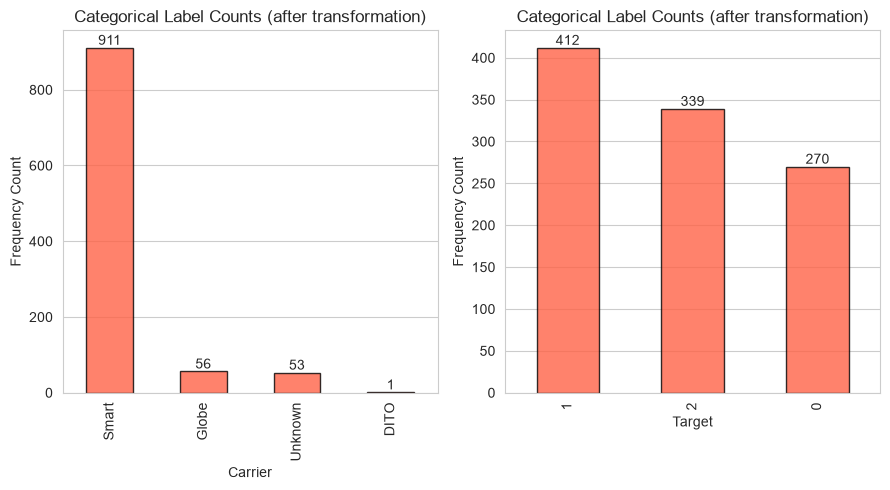

In [76]:
categoricals = ['carrier', 'target']

fig, ax = plt.subplots(1, 2, figsize=(9, 5))

sns.set_style('whitegrid')
for i, cats in enumerate(categoricals):
    counts = clean[cats].value_counts().sort_values(ascending=False)
    counts.plot(kind='bar', alpha=0.8, ax=ax[i], edgecolor='black', color='tomato')
    ax[i].set_ylabel('Frequency Count')
    ax[i].set_xlabel(f"{cats.title()}")
    ax[i].set_title('Categorical Label Counts (after transformation)')
    ax[i].bar_label(ax[i].containers[0])
    ax[i].grid(axis='x')
plt.tight_layout()

Text(0.5, 1.0, 'Scam Messages by Months')

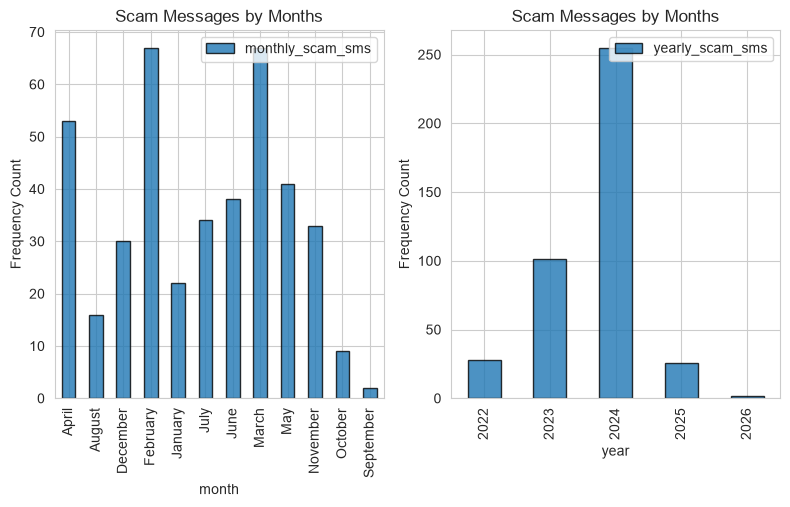

In [77]:
monthly_smishing = clean[clean['target'] == 1]
monthly_smishing = monthly_smishing.groupby('month').agg(
    monthly_scam_sms = ('target', 'count')
)

yearly_smishing = clean[clean['target'] == 1]
yearly_smishing = yearly_smishing.groupby('year').agg(
    yearly_scam_sms = ('target', 'count')
)

fig, axes = plt.subplots(1, 2, figsize=(8, 5))

monthly_smishing.plot(kind='bar', edgecolor='black', alpha=.8, ax=axes[0])
yearly_smishing.plot(kind='bar', edgecolor='black', alpha=.8, ax=axes[1])
axes[0].set_ylabel('Frequency Count')
axes[1].set_ylabel('Frequency Count')
plt.tight_layout()
axes[0].set_title('Scam Messages by Months')
axes[1].set_title('Scam Messages by Months')

In [78]:
monthly_smishing.sort_values('monthly_scam_sms', ascending=False)

,monthly_scam_sms
month,
February,67
March,67
April,53
May,41
June,38
July,34
November,33
December,30
January,22


In [79]:
yearly_smishing.sort_values('yearly_scam_sms', ascending=False)

,yearly_scam_sms
year,
2024,255
2023,101
2022,28
2025,26
2026,2


Text(0, 0.5, 'Frequency Count')

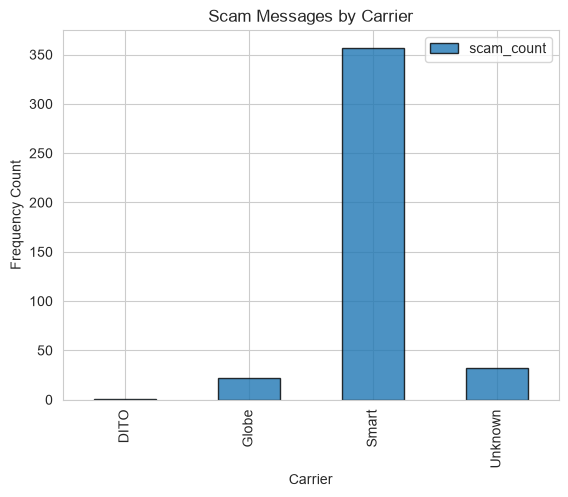

In [80]:
carrier_by_scam = clean[clean['target'] == 1]
carrier_by_scam = carrier_by_scam.groupby('carrier').agg(
    scam_count = ('target', 'count')
)

carrier_by_scam.plot(kind='bar', alpha=0.8, edgecolor='black')
plt.title('Scam Messages by Carrier')
plt.xlabel('Carrier')
plt.ylabel('Frequency Count')

## Feature Significance

<Axes: >

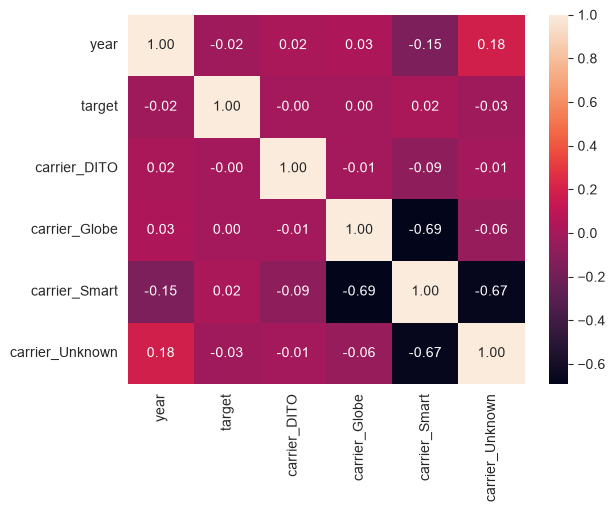

In [81]:
# one hot encode carriers
clean = pd.get_dummies(clean, columns=['carrier'], dtype='int')

# corr heatmap
sns.heatmap(clean.corr(numeric_only=True), annot=True, fmt='.2f')

Text(0.5, 1.0, 'Feature Significance')

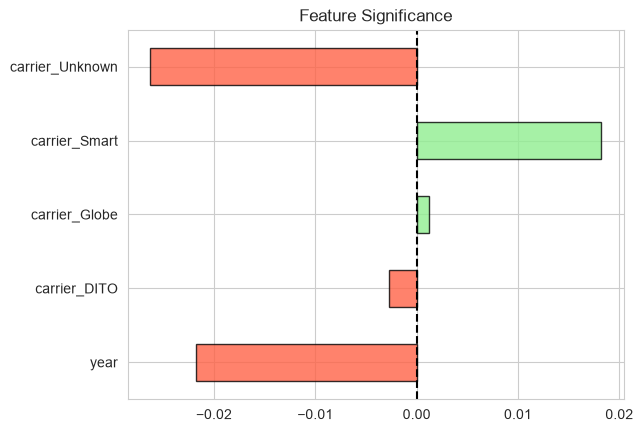

In [86]:
feature_sig = clean.corr(numeric_only=True)['target'].drop('target', axis=0)

color_lbls = ['lightgreen' if corr > 0 else 'tomato' for corr in feature_sig]
feature_sig.plot(kind='barh', color=color_lbls, edgecolor='black', alpha=0.8)
plt.axvline(x=0, color='black', linestyle='--')
plt.title('Feature Significance')

## Feature Engineering (Text)

## Load the Transformed Dataset